In [1]:
import os
hf_token = os.getenv("HF_TOKEN")

import re

from sklearn.model_selection import train_test_split
import gensim.downloader     #na nacitanie predtrenovaneho word2vec modelu
from nltk.tokenize import word_tokenize
import nltk     #natural language processing
nltk.download('punkt', quiet=True)

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec
from transformers import AutoTokenizer, AutoModel
import torch

from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
from src.ML.train_rf import train_random_forest
from src.data_loader import load_data
from src.ML.train_svm import train_SVM

In [2]:
# Load data
df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


In [3]:
print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64



RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------
Original class weights: [0.68688119 1.83774834]
Boosted class weights: [0.68688119 3.85927152]
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Random Forest parameters found via StratifiedKFold: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0     0.8485    0.2772    0.4179       101
           1     0.3113    0.8684    0.4583        38

    accura

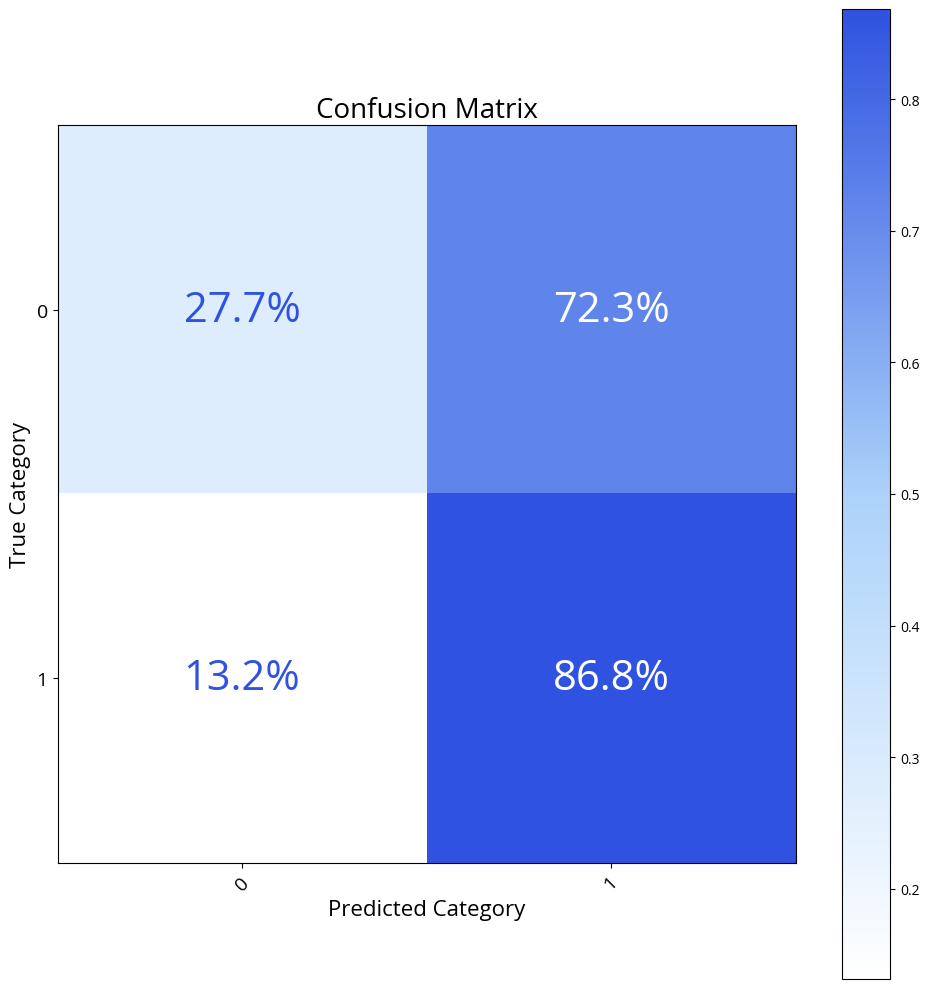

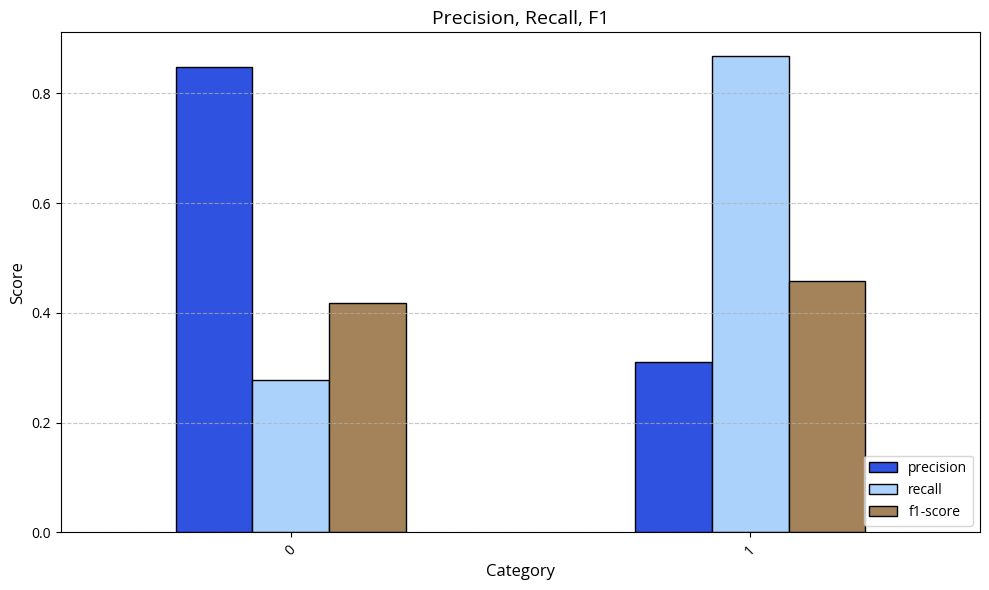

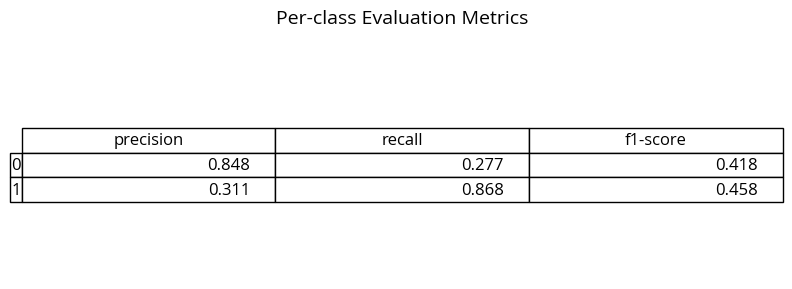

In [4]:
# Random Forest - MiniLM
rf_model = train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 2.1)


SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------

Computed class weights:
  0: 0.6869
  1: 5.5132

Best C found via StratifiedKFold: 0.01

--- SVM CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0     0.8519    0.2277    0.3594       101
           1     0.3036    0.8947    0.4533        38

    accuracy                         0.4101       139
   macro avg     0.5777    0.5612    0.4064       139
weighted avg     0.7020    0.4101    0.3851       139



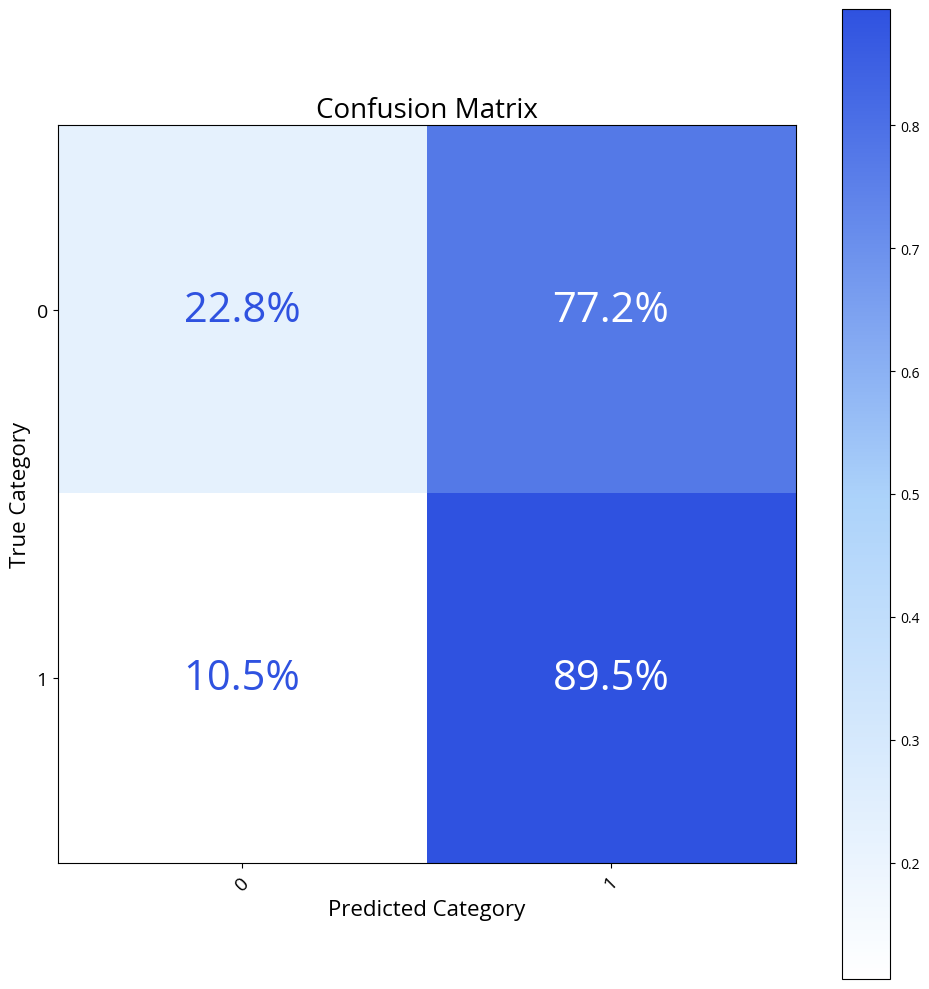

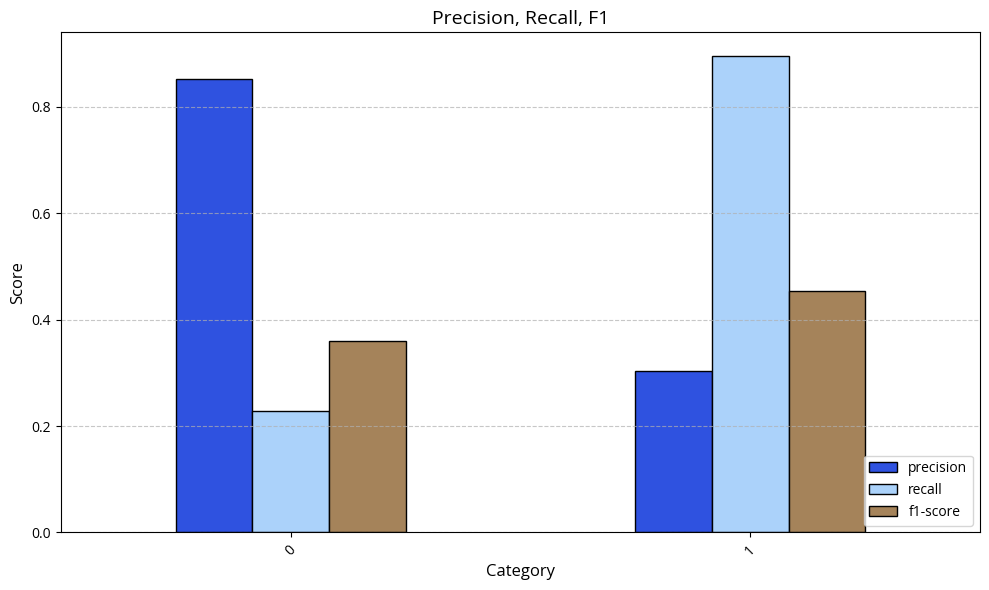

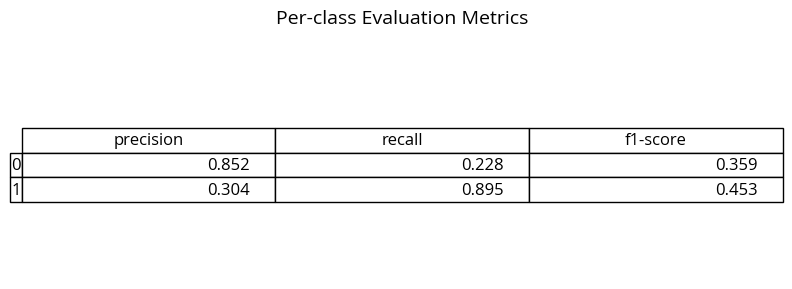

In [5]:
# SVM - MiniLM
svm_model = train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 3.0)
